In [1]:
import os
from pathlib import Path
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils import data
from torchvision import transforms
import glob
from PIL import Image
from tqdm.auto import tqdm

In [2]:
torch.cuda.is_available()

True

In [ ]:
DATASET_CONFIGS = {
    'anime': {
        'dataset_type': 'concat_pair_image',
        'train_glob': '../input/datasets/ktaebum/anime-sketch-colorization-pair/data/train/*.png',
        'val_glob': '../input/datasets/ktaebum/anime-sketch-colorization-pair/data/val/*.png',
        'img_size': 256,
        'per_gpu_batch_size': 128,
        'epochs': 20,
        'g_lr': 1e-3,
        'd_lr': 1e-4,
        'g_steps': 2,
        'preview_every': 1,
        'use_amp': True,
        'use_data_parallel': True,
        'use_channels_last': True,
        'scale_batch_with_gpus': True,
        'num_workers': 0,
        'checkpoint_every': 1,
         'persistent_workers': True,
        'prefetch_factor': 2,
    },
    'cufs': {
        'dataset_type': 'separate_sketch_photo',
        'train_sketch_glob': '../input/cuhk-face-sketch-database-cufs/train/sketch/*.*',
        'train_photo_glob': '../input/cuhk-face-sketch-database-cufs/train/photo/*.*',
        'val_sketch_glob': '../input/cuhk-face-sketch-database-cufs/val/sketch/*.*',
        'val_photo_glob': '../input/cuhk-face-sketch-database-cufs/val/photo/*.*',
        'img_size': 256,
        'per_gpu_batch_size': 128,
        'epochs': 20,
        'g_lr': 1e-4,
        'd_lr': 1e-4,
        'g_steps': 3,
        'preview_every': 1,
        'use_amp': True,
        'use_data_parallel': True,
        'use_channels_last': True,
        'scale_batch_with_gpus': True,
        'num_workers': 0,
        'checkpoint_every': 1,
          'persistent_workers': True,
        'prefetch_factor': 2,
        'resume_training': True
    }
}

ACTIVE_DATASET = 'anime'
cfg = DATASET_CONFIGS[ACTIVE_DATASET]

In [4]:
if cfg['dataset_type'] == 'concat_pair_image':
    train_preview_paths = sorted(glob.glob(cfg['train_glob']))
else:
    train_preview_paths = sorted(glob.glob(cfg['train_sketch_glob']))

len(train_preview_paths)

14224

In [5]:
train_preview_paths[:4]

['../input/datasets/ktaebum/anime-sketch-colorization-pair/data/train/1000000.png',
 '../input/datasets/ktaebum/anime-sketch-colorization-pair/data/train/10001.png',
 '../input/datasets/ktaebum/anime-sketch-colorization-pair/data/train/10007.png',
 '../input/datasets/ktaebum/anime-sketch-colorization-pair/data/train/10010.png']

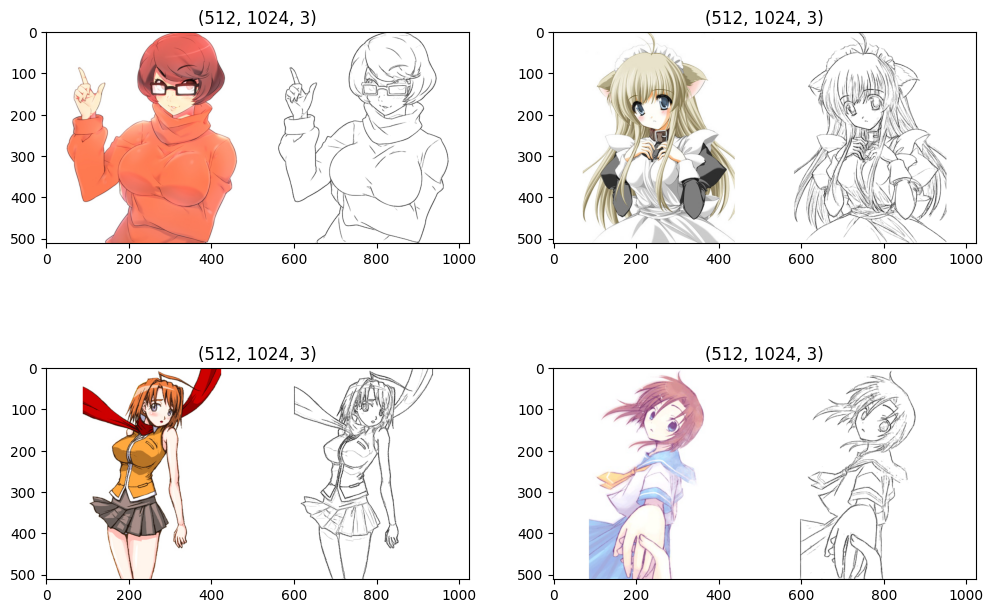

In [6]:
plt.figure(figsize=(12, 8))
for i, img_path in enumerate(train_preview_paths[:4]):
    img = Image.open(img_path).convert('RGB')
    np_img = np.array(img)
    plt.subplot(2, 2, i + 1)
    plt.imshow(np_img)
    plt.title(str(np_img.shape))
plt.show()

In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((cfg['img_size'], cfg['img_size'] * 2)),
    transforms.Normalize(0.5, 0.5)
])

target_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((cfg['img_size'], cfg['img_size'])),
    transforms.Normalize(0.5, 0.5)
])

In [8]:
class AnimePairDataset(data.Dataset):
    def __init__(self, imgs_path, transform):
        self.imgs_path = sorted(imgs_path)
        self.transform = transform

    def __getitem__(self, index):
        img_path = self.imgs_path[index]
        pil_img = Image.open(img_path).convert('RGB')
        pil_img = self.transform(pil_img)
        w = pil_img.size(2) // 2
        sketch = pil_img[:, :, w:]
        color = pil_img[:, :, :w]
        return sketch, color
        
    def __len__(self):
        return len(self.imgs_path)


class CUFSPairedDataset(data.Dataset):
    def __init__(self, sketch_paths, photo_paths, target_transform):
        sketch_map = {Path(p).stem: p for p in sorted(sketch_paths)}
        photo_map = {Path(p).stem: p for p in sorted(photo_paths)}
        common_keys = sorted(set(sketch_map).intersection(photo_map))
        self.pairs = [(sketch_map[k], photo_map[k]) for k in common_keys]
        self.target_transform = target_transform

    def __getitem__(self, index):
        sketch_path, photo_path = self.pairs[index]
        sketch = Image.open(sketch_path).convert('RGB')
        photo = Image.open(photo_path).convert('RGB')
        sketch = self.target_transform(sketch)
        photo = self.target_transform(photo)
        return sketch, photo

    def __len__(self):
        return len(self.pairs)


def build_datasets(cfg):
    if cfg['dataset_type'] == 'concat_pair_image':
        train_paths = glob.glob(cfg['train_glob'])
        val_paths = glob.glob(cfg['val_glob'])
        train_dataset = AnimePairDataset(train_paths, transform)
        val_dataset = AnimePairDataset(val_paths, transform)
    else:
        train_sketch = glob.glob(cfg['train_sketch_glob'])
        train_photo = glob.glob(cfg['train_photo_glob'])
        val_sketch = glob.glob(cfg['val_sketch_glob'])
        val_photo = glob.glob(cfg['val_photo_glob'])
        train_dataset = CUFSPairedDataset(train_sketch, train_photo, target_transform)
        val_dataset = CUFSPairedDataset(val_sketch, val_photo, target_transform)
    return train_dataset, val_dataset

In [9]:
dataset, test_dataset = build_datasets(cfg)
gpu_count = max(1, torch.cuda.device_count())

base_batch = cfg.get('per_gpu_batch_size', 16)
batchsize = base_batch * gpu_count if cfg.get('scale_batch_with_gpus', True) else base_batch
num_workers = cfg.get('num_workers', 4)

loader_kwargs = {
    'batch_size': batchsize,
    'pin_memory': True,
    'num_workers': num_workers
}
if num_workers > 0:
    loader_kwargs['persistent_workers'] = True
    loader_kwargs['prefetch_factor'] = 2

dataloader = data.DataLoader(dataset, shuffle=True, drop_last=True, **loader_kwargs)
test_dataloader = data.DataLoader(test_dataset, shuffle=False, **loader_kwargs)

print('Active dataset:', ACTIVE_DATASET)
print('Detected GPUs:', gpu_count)
print('Train samples:', len(dataset))
print('Val samples:', len(test_dataset))
print('Effective batch size:', batchsize)

Active dataset: anime
Detected GPUs: 2
Train samples: 14224
Val samples: 3545
Effective batch size: 256


torch.Size([256, 3, 256, 256])


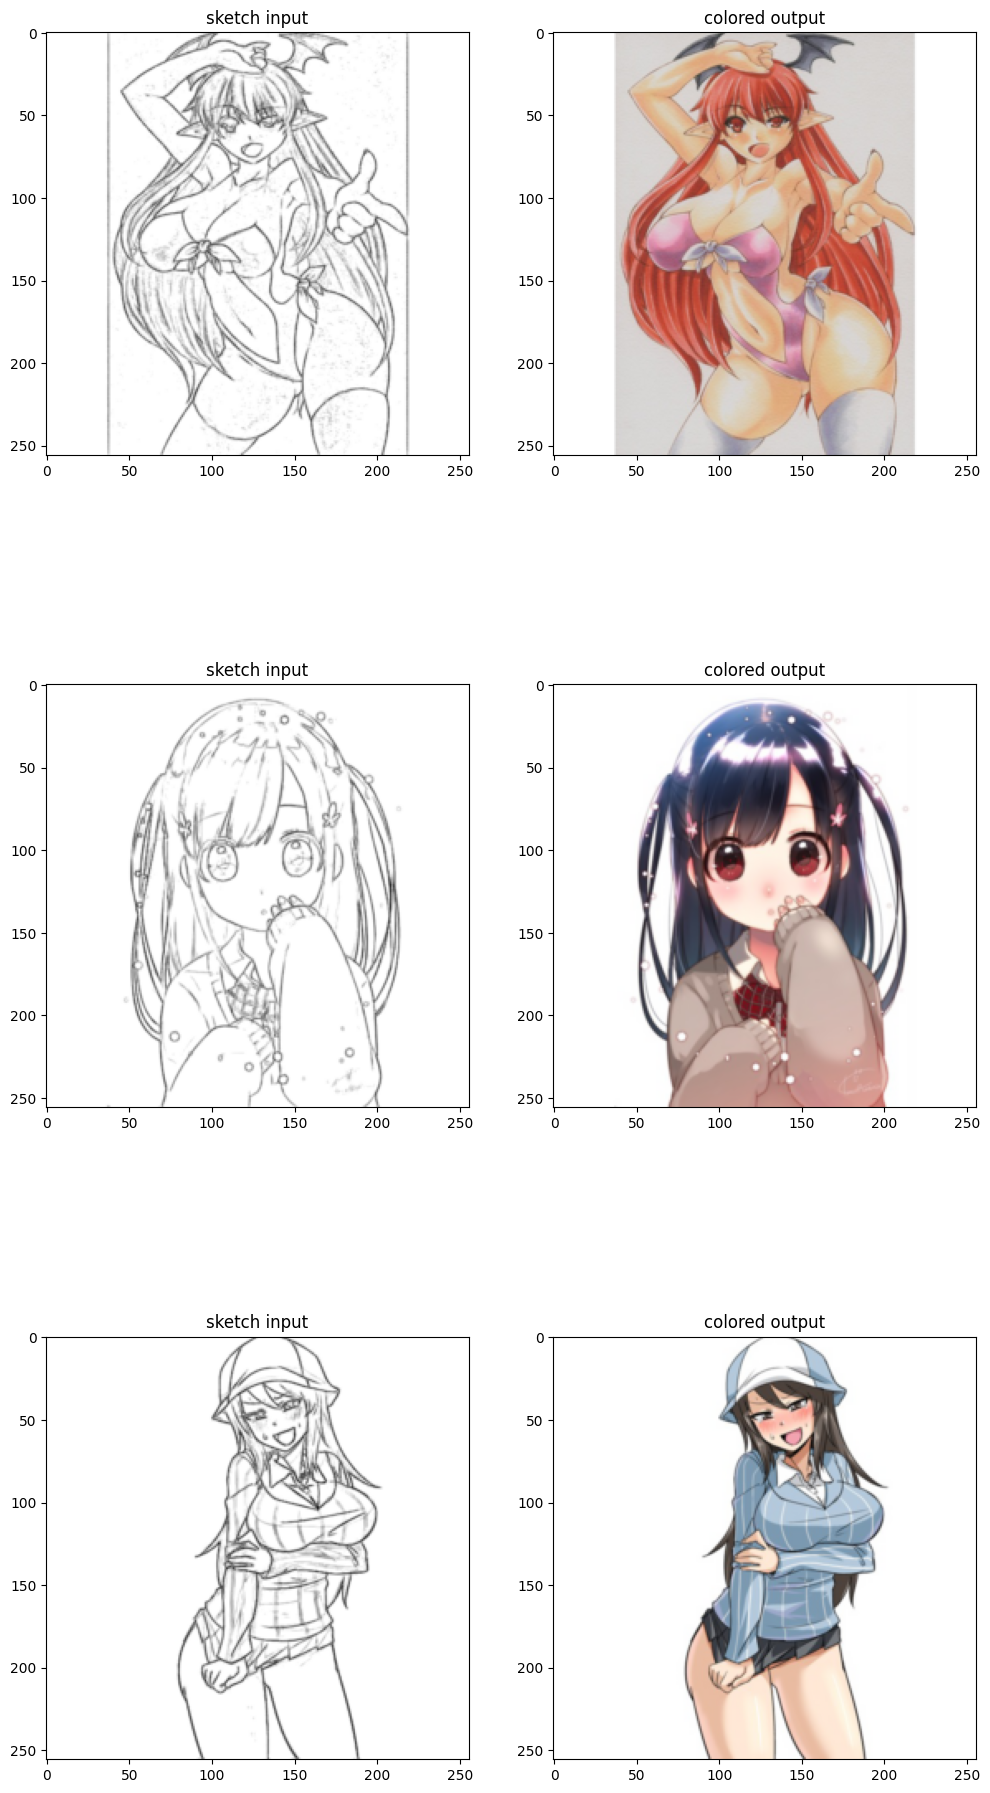

In [10]:

imgs_batch, masks_batch = next(iter(dataloader))
print(imgs_batch.shape)

plt.figure(figsize=(12, 24))
for i, (img, mask) in enumerate(zip(imgs_batch[:3], masks_batch[:3])):
    img = (img.permute(1, 2, 0).numpy() + 1) / 2
    mask = (mask.permute(1, 2, 0).numpy() + 1) / 2
    plt.subplot(3, 2, 2*i+1)
    plt.title('sketch input')
    plt.imshow(img)
    plt.subplot(3, 2, 2 * i + 2)
    plt.title('colored output')
    plt.imshow(mask)

plt.show()

In [11]:

class Downsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Downsample, self).__init__()
        self.conv_relu = nn.Sequential(  
            nn.Conv2d(in_channels, out_channels, 
                      kernel_size=3,
                      stride=2,
                      padding=1),
            nn.LeakyReLU(inplace=True), 
        )
        self.bn = nn.BatchNorm2d(out_channels)

    
    def forward(self, x, is_bn=True):
        x = self.conv_relu(x)  
        if is_bn:  
            x = self.bn(x)
        return x

In [12]:

class Upsample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(Upsample, self).__init__()
        self.upconv_relu = nn.Sequential( 
            nn.ConvTranspose2d(in_channels, out_channels,  
                               kernel_size=3,
                               stride=2,
                               padding=1,
                               output_padding=1),
            nn.LeakyReLU(inplace=True),  
        )
        self.bn = nn.BatchNorm2d(out_channels)

   
    def forward(self, x, is_drop=False):
        x = self.upconv_relu(x)  
        x = self.bn(x)  
        if is_drop:  
            x = F.dropout2d(x)
        return x

In [13]:

class Generator(nn.Module):  
    def __init__(self):
        super(Generator, self).__init__()
        
        self.down1 = Downsample(3, 64)  
        self.down2 = Downsample(64, 128)  
        self.down3 = Downsample(128, 256) 
        self.down4 = Downsample(256, 512)  
        self.down5 = Downsample(512, 512)  
        self.down6 = Downsample(512, 512) 

       
        self.up1 = Upsample(512, 512)  
       
        self.up2 = Upsample(1024, 512) 
        self.up3 = Upsample(1024, 256)  
        self.up4 = Upsample(512, 128)  
        self.up5 = Upsample(256, 64)  

        self.last = nn.ConvTranspose2d(128, 3,
                                       kernel_size=3,
                                       stride=2,
                                       padding=1,
                                       output_padding=1)

    def forward(self, x):  
        
        x1 = self.down1(x)  
        x2 = self.down2(x1)  
        x3 = self.down3(x2) 
        x4 = self.down4(x3)  
        x5 = self.down5(x4) 
        x6 = self.down6(x5)  
       
      
        x6 = self.up1(x6, is_drop=True) 
        x6 = torch.cat([x6, x5], dim=1)  

        x6 = self.up2(x6, is_drop=True)  
        x6 = torch.cat([x6, x4], dim=1)  

        x6 = self.up3(x6, is_drop=True) 
        x6 = torch.cat([x6, x3], dim=1) 

      
        x6 = self.up4(x6) 
        x6 = torch.cat([x6, x2], dim=1)

        x6 = self.up5(x6)  
        x6 = torch.cat([x6, x1], dim=1)  
       
        x = torch.tanh(self.last(x6))  
        return x

In [14]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        # 256x256 -> 128 -> 64 -> 32 -> 16
        self.down1 = Downsample(6, 64)
        self.down2 = Downsample(64, 128)
        self.down3 = Downsample(128, 256)
        self.down4 = Downsample(256, 512)
        self.last = nn.Conv2d(512, 1, kernel_size=3, padding=1)

    def forward(self, img, mask):
        x = torch.cat([img, mask], dim=1)
        x = self.down1(x, is_bn=False)
        x = self.down2(x)
        x = self.down3(x)
        x = self.down4(x)
        
        return x

In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
gpu_count = torch.cuda.device_count() if device == 'cuda' else 0

if device == 'cuda':
    torch.backends.cudnn.benchmark = True

G = Generator().to(device)
D = Discriminator().to(device)

if cfg.get('use_channels_last', True) and device == 'cuda':
    G = G.to(memory_format=torch.channels_last)
    D = D.to(memory_format=torch.channels_last)

use_data_parallel = cfg.get('use_data_parallel', True) and gpu_count >= 2
if use_data_parallel:
    G = nn.DataParallel(G)
    D = nn.DataParallel(D)

G_optim = torch.optim.Adam(G.parameters(), lr=cfg['g_lr'], betas=(0.5, 0.999))
D_optim = torch.optim.Adam(D.parameters(), lr=cfg['d_lr'], betas=(0.5, 0.999))

amp_enabled = cfg.get('use_amp', True) and device == 'cuda'
scaler = torch.amp.GradScaler(device, enabled=amp_enabled)

def unwrap_model(model):
    return model.module if hasattr(model, 'module') else model

def strip_module_prefix(state_dict):
    if any(k.startswith('module.') for k in state_dict.keys()):
        return {k.replace('module.', '', 1): v for k, v in state_dict.items()}
    return state_dict

is_kaggle = os.getenv('KAGGLE_KERNEL_RUN_TYPE') is not None
checkpoint_root = '/kaggle/working/checkpoints' if is_kaggle else os.path.join(os.getcwd(), 'checkpoints')
save_dir = os.path.join(checkpoint_root, ACTIVE_DATASET)

epoch_ckpt_dir = os.path.join(save_dir, 'epochs')
os.makedirs(epoch_ckpt_dir, exist_ok=True)
# Keep folder non-empty so it remains visible in some notebook file browsers
keep_path = os.path.join(save_dir, 'KEEP.txt')
if not os.path.exists(keep_path):
    with open(keep_path, 'w', encoding='utf-8') as f:
        f.write('Checkpoint directory for training outputs.\n')

start_epoch = 0
if cfg.get('resume_training', True):
    epoch_ckpts = sorted(glob.glob(os.path.join(epoch_ckpt_dir, 'epoch_*.pt')))
    if epoch_ckpts:
        latest_ckpt_path = epoch_ckpts[-1]
        ckpt = torch.load(latest_ckpt_path, map_location=device)

        unwrap_model(G).load_state_dict(strip_module_prefix(ckpt['G_state_dict']))
        unwrap_model(D).load_state_dict(strip_module_prefix(ckpt['D_state_dict']))
        G_optim.load_state_dict(ckpt['G_optimizer_state_dict'])
        D_optim.load_state_dict(ckpt['D_optimizer_state_dict'])

        if amp_enabled and ckpt.get('scaler_state_dict') is not None:
            scaler.load_state_dict(ckpt['scaler_state_dict'])

        start_epoch = int(ckpt.get('epoch', 0))
        print(f"Resumed from {latest_ckpt_path} at epoch {start_epoch}")
    else:
        print('No epoch checkpoint found. Starting from epoch 0.')
print('AMP enabled:', amp_enabled)
print('DataParallel enabled:', use_data_parallel)
print('CUDA GPUs visible:', gpu_count)
print('Checkpoint root:', checkpoint_root)
print('Dataset checkpoint dir:', save_dir)

No epoch checkpoint found. Starting from epoch 0.
AMP enabled: True
DataParallel enabled: True
CUDA GPUs visible: 2
Checkpoint root: /kaggle/working/checkpoints
Dataset checkpoint dir: /kaggle/working/checkpoints/anime


In [16]:

loss1 = torch.nn.BCEWithLogitsLoss()
loss2 = torch.nn.L1Loss()
LAMBDA = 7  

In [17]:

def gen_img_plot(model, img, mask):  

    predictions = np.squeeze(model(img).permute(0, 2, 3, 1).detach().cpu().numpy())  
    img = img.permute(0, 2, 3, 1).cpu().numpy()
    mask = mask.permute(0, 2, 3, 1).cpu().numpy()
    plt.figure(figsize=(10, 10))  
    display_list = [img[0], mask[0], predictions[0]]
    title = ['Sketch Input', 'Color Target', 'Generated Color']
    for i in range(3): 
        plt.subplot(1, 3, i + 1) 
        plt.title(title[i])
       
        plt.imshow((display_list[i] + 1) / 2)
        plt.axis('off') 
    
    plt.show() 

In [18]:
imgs_batch, masks_batch = next(iter(test_dataloader))

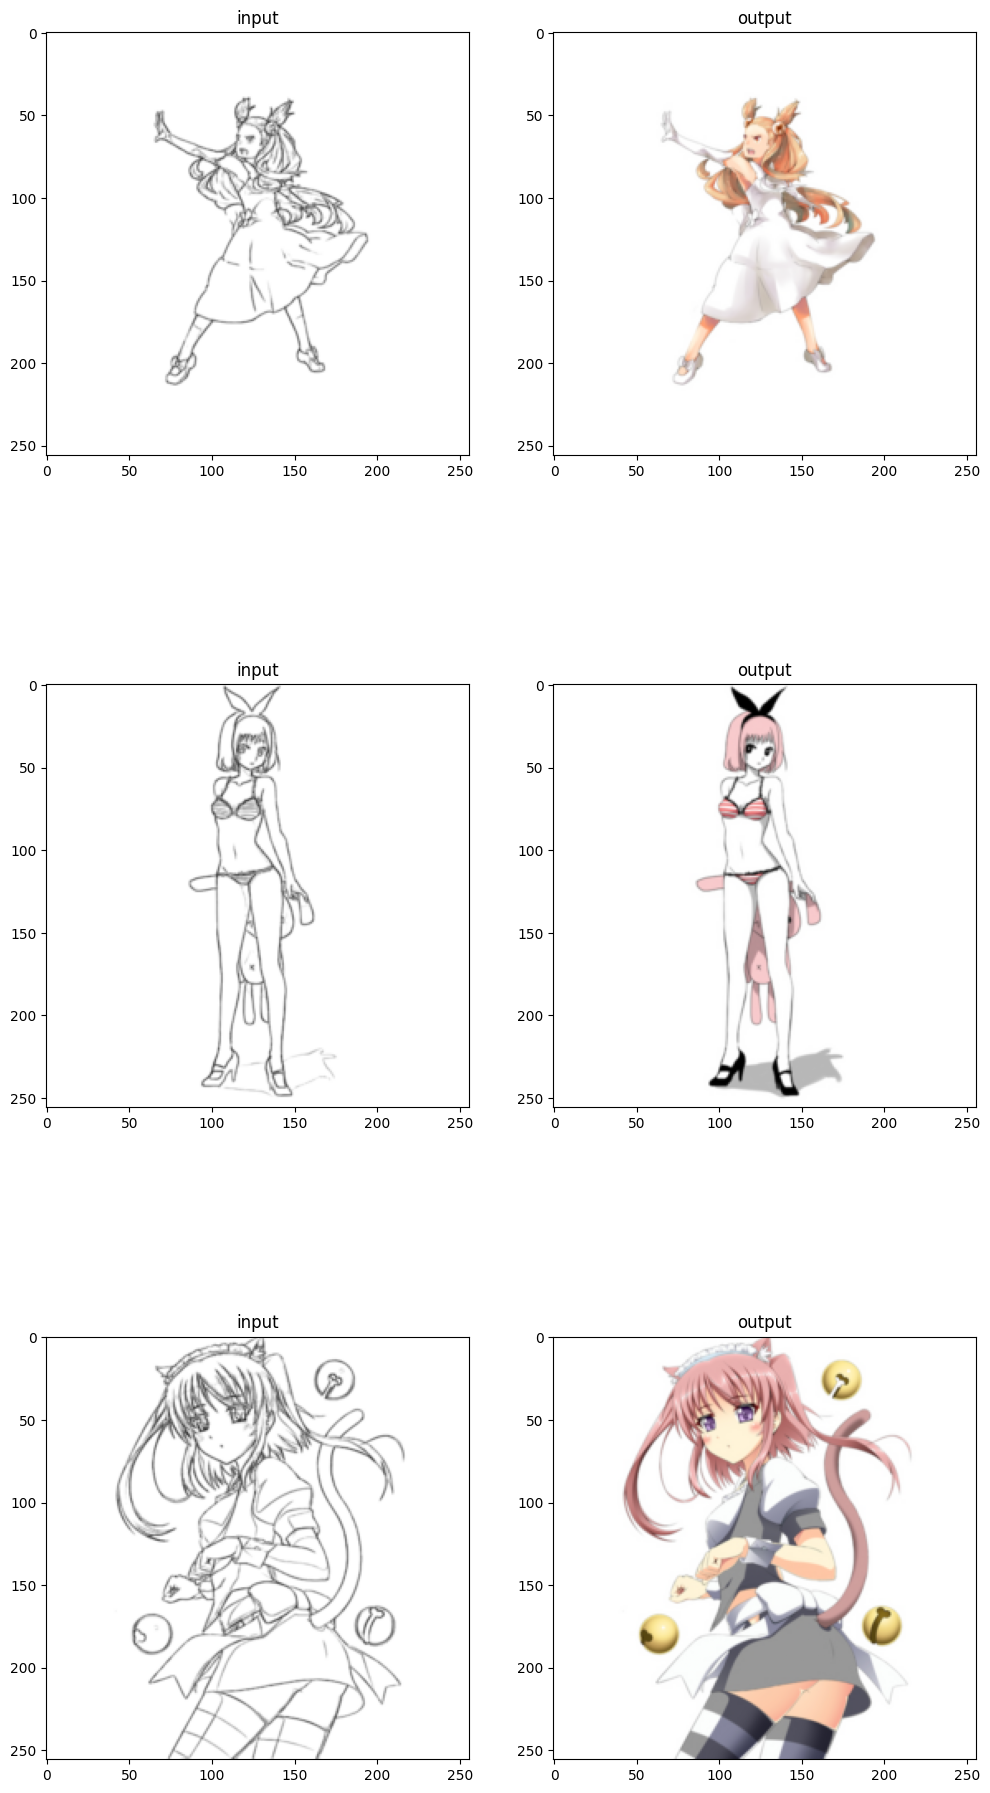

In [19]:
plt.figure(figsize=(12, 24))
for i, (img, mask) in enumerate(zip(imgs_batch[:3], masks_batch[:3])):
    img = (img.permute(1, 2, 0).numpy() + 1) / 2
    mask = (mask.permute(1, 2, 0).numpy() + 1) / 2
    plt.subplot(3, 2, 2*i+1)
    plt.title('input')
    plt.imshow(img)
    plt.subplot(3, 2, 2 * i + 2)
    plt.title('output')
    plt.imshow(mask)

plt.show()
imgs_batch = imgs_batch.to(device)
masks_batch = masks_batch.to(device)

In [20]:
D_loss_list = [] 
G_loss_list = []

Epochs:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epochs:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 1/20 | D_loss=1.4675 G_loss=3.1982 D_acc=0.497 G_fool_acc=0.304


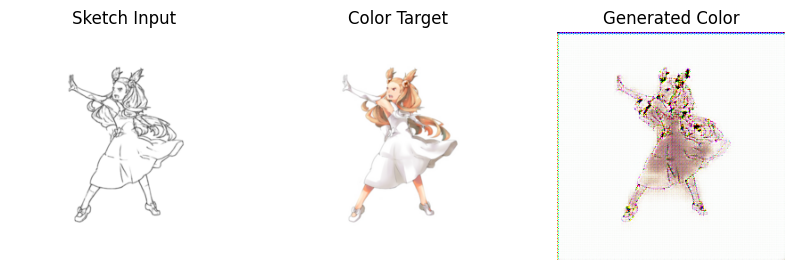

Epoch 2/20 | D_loss=1.4084 G_loss=2.1363 D_acc=0.504 G_fool_acc=0.193


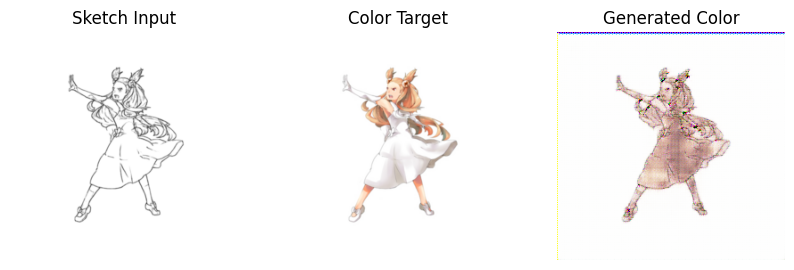

Epoch 3/20 | D_loss=1.4014 G_loss=1.8920 D_acc=0.475 G_fool_acc=0.169


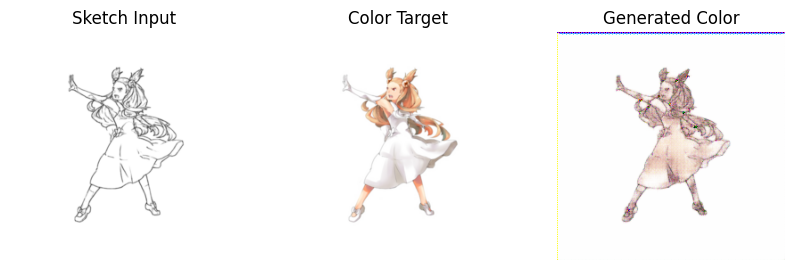

Epoch 4/20 | D_loss=1.4036 G_loss=1.7929 D_acc=0.464 G_fool_acc=0.209


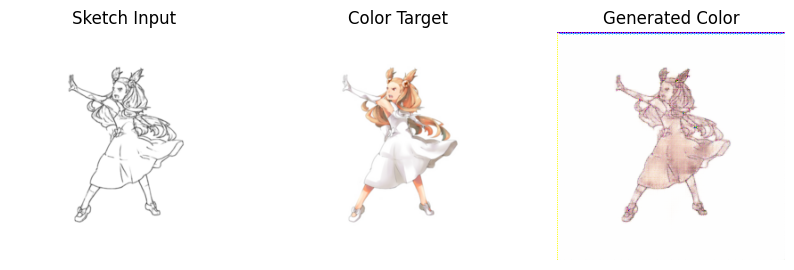

Epoch 5/20 | D_loss=1.3992 G_loss=1.7183 D_acc=0.427 G_fool_acc=0.463


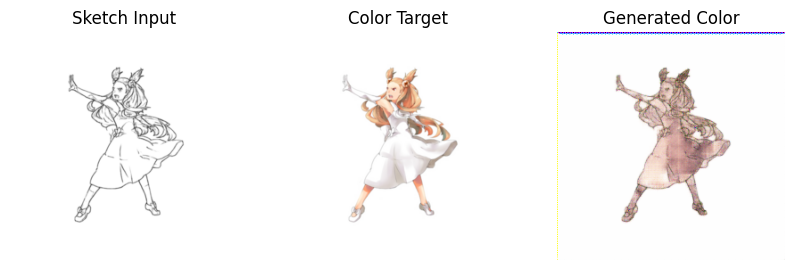

Epoch 6/20 | D_loss=1.3980 G_loss=1.6430 D_acc=0.412 G_fool_acc=0.533


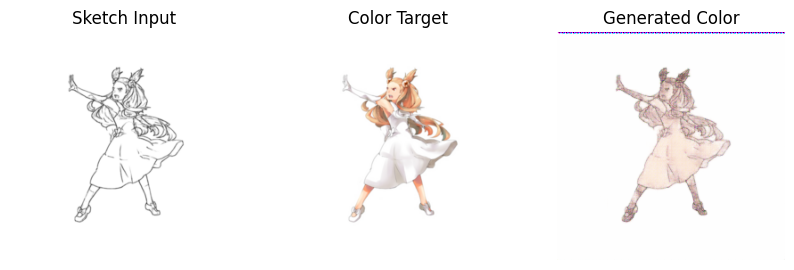

Epoch 7/20 | D_loss=1.3973 G_loss=1.5780 D_acc=0.389 G_fool_acc=0.605


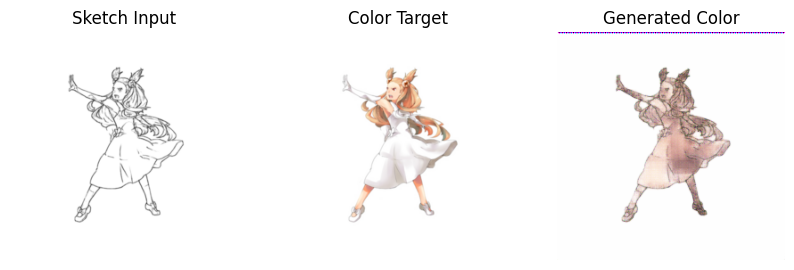

Epoch 8/20 | D_loss=1.3963 G_loss=1.5293 D_acc=0.392 G_fool_acc=0.680


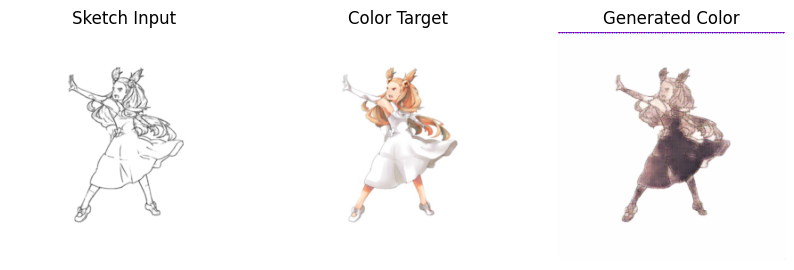

Epoch 9/20 | D_loss=1.3961 G_loss=1.4910 D_acc=0.417 G_fool_acc=0.686


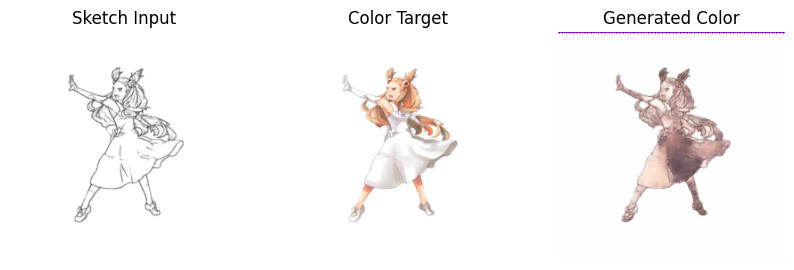

Epoch 10/20 | D_loss=1.3953 G_loss=1.4578 D_acc=0.400 G_fool_acc=0.737


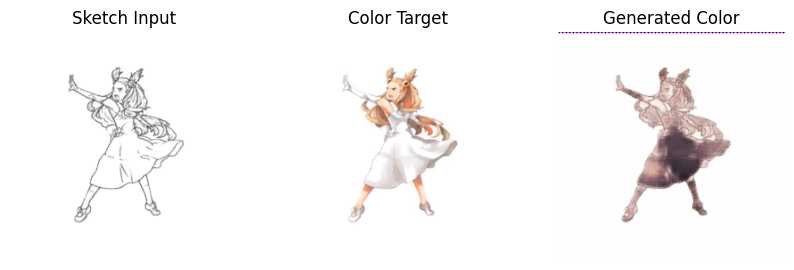

Epoch 11/20 | D_loss=1.3949 G_loss=1.4253 D_acc=0.406 G_fool_acc=0.736


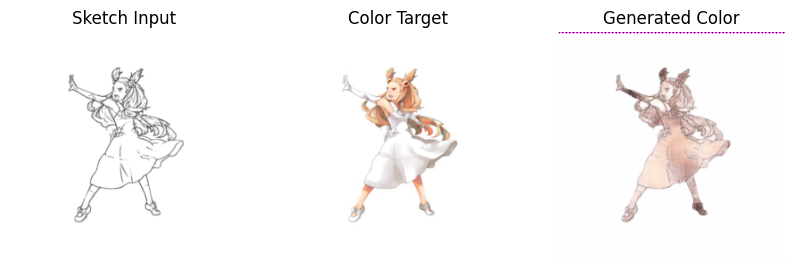

Epoch 12/20 | D_loss=1.3949 G_loss=1.4023 D_acc=0.389 G_fool_acc=0.744


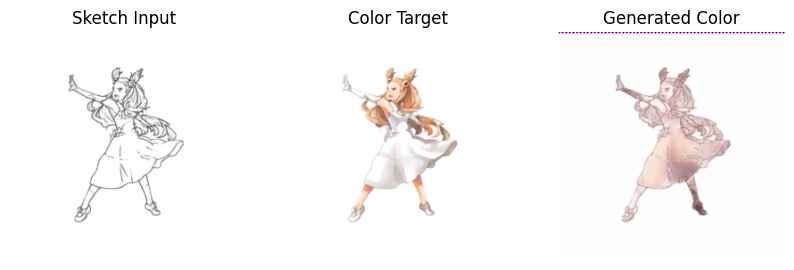

Epoch 13/20 | D_loss=1.3945 G_loss=1.3930 D_acc=0.397 G_fool_acc=0.739


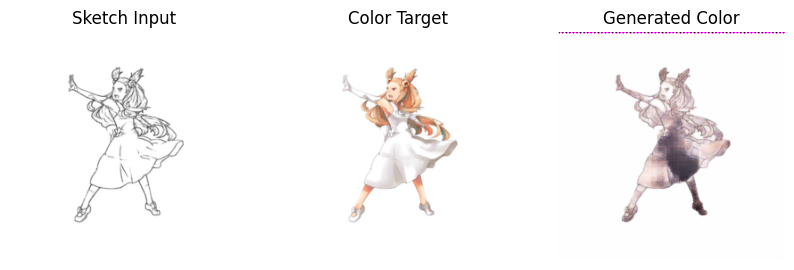

Epoch 14/20 | D_loss=1.3947 G_loss=1.3720 D_acc=0.392 G_fool_acc=0.718


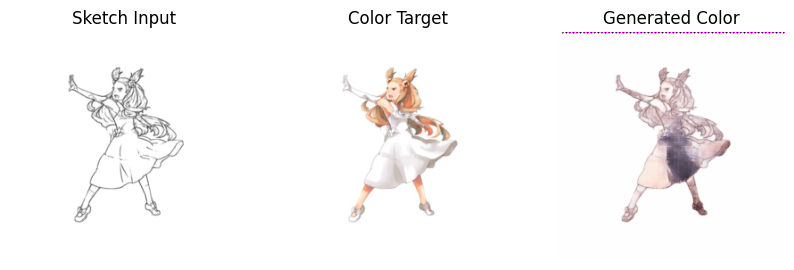

Epoch 15/20 | D_loss=1.3946 G_loss=1.3526 D_acc=0.372 G_fool_acc=0.722


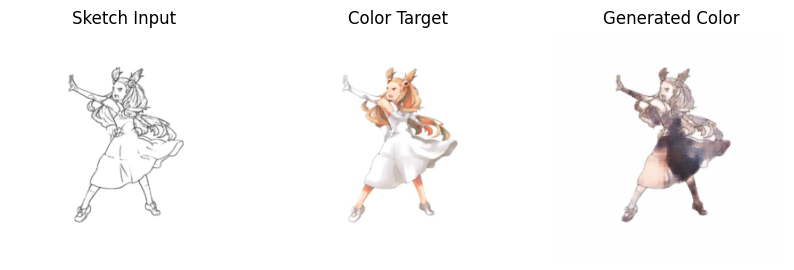

Epoch 16/20 | D_loss=1.3950 G_loss=1.3133 D_acc=0.359 G_fool_acc=0.711


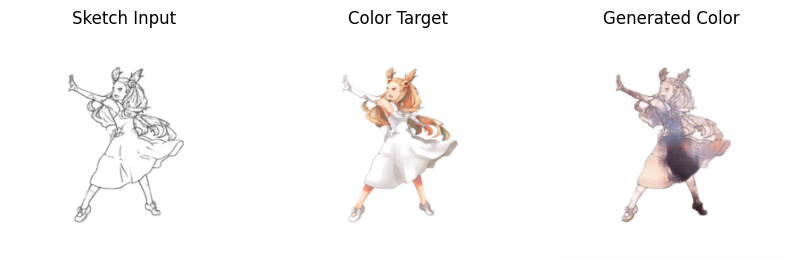

Epoch 17/20 | D_loss=1.3951 G_loss=1.2982 D_acc=0.361 G_fool_acc=0.718


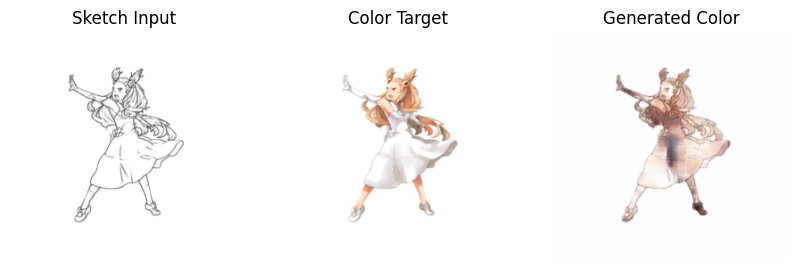

Epoch 18/20 | D_loss=1.3952 G_loss=1.2842 D_acc=0.369 G_fool_acc=0.708


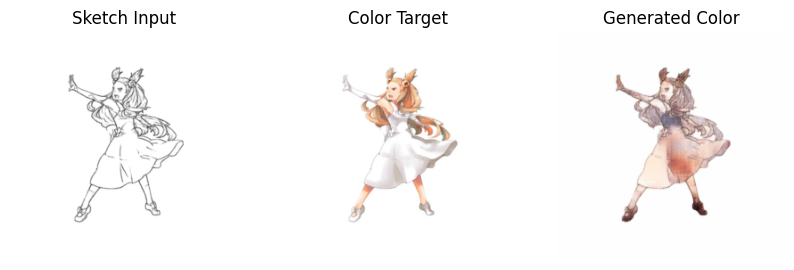

Epoch 19/20 | D_loss=1.3946 G_loss=1.2724 D_acc=0.407 G_fool_acc=0.718


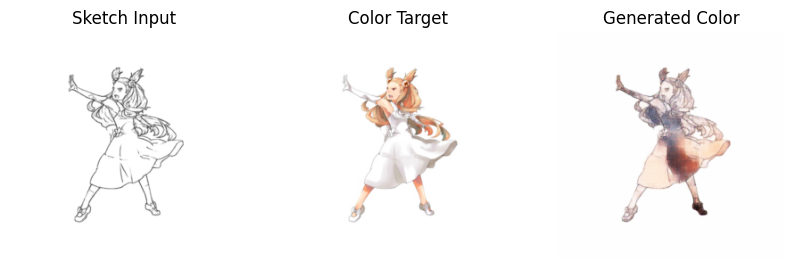

Epoch 20/20 | D_loss=1.3940 G_loss=1.2621 D_acc=0.377 G_fool_acc=0.765


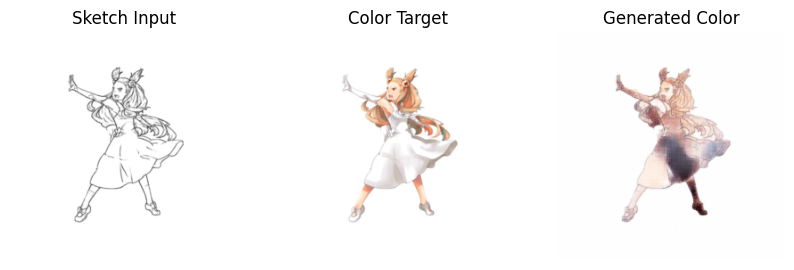

In [21]:
epoch_bar = tqdm(range(cfg['epochs']), desc='Epochs', unit='epoch')
if start_epoch >= cfg['epochs']:
    print(f"Checkpoint already at epoch {start_epoch}. No remaining epochs to run.")

epoch_bar = tqdm(range(start_epoch, cfg['epochs']), desc='Epochs', unit='epoch')
for epoch in epoch_bar:
    D_epoch_loss = 0.0
    G_epoch_loss = 0.0
    D_real_acc_epoch = 0.0
    D_fake_acc_epoch = 0.0
    G_fool_acc_epoch = 0.0
    count = len(dataloader)

    for step, (imgs, masks) in enumerate(dataloader):
        imgs = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if cfg.get('use_channels_last', True) and device == 'cuda':
            imgs = imgs.contiguous(memory_format=torch.channels_last)
            masks = masks.contiguous(memory_format=torch.channels_last)

        D_optim.zero_grad(set_to_none=True)
        # Reuse a no-grad generator pass for D-step fake samples
        with torch.no_grad():
            with torch.amp.autocast(device_type=device, enabled=amp_enabled):
                G_img_for_d = G(imgs)
        with torch.amp.autocast(device_type=device, enabled=amp_enabled):
            D_real = D(imgs, masks)
            D_real_loss = loss1(D_real, torch.ones_like(D_real))

            D_fake = D(imgs, G_img_for_d)
            D_fake_loss = loss1(D_fake, torch.zeros_like(D_fake))

            D_loss = D_real_loss + D_fake_loss

        scaler.scale(D_loss).backward()
        scaler.step(D_optim)
        scaler.update()
        with torch.no_grad():
            D_real_acc_epoch += (torch.sigmoid(D_real) >= 0.5).float().mean().item()
            D_fake_acc_epoch += (torch.sigmoid(D_fake) < 0.5).float().mean().item()

        G_loss = 0.0
        g_fool_acc_step = 0.0
        g_steps = cfg.get('g_steps', 1)

        for _ in range(g_steps):
            G_optim.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device, enabled=amp_enabled):
                G_img = G(imgs)
                D_fake_for_g = D(imgs, G_img)
                G_loss_BCE = loss1(D_fake_for_g, torch.ones_like(D_fake_for_g))
                G_loss_L1 = loss2(G_img, masks)
                G_loss = G_loss_BCE + LAMBDA * G_loss_L1

            scaler.scale(G_loss).backward()
            scaler.step(G_optim)
            scaler.update()

            with torch.no_grad():
                g_fool_acc_step += (torch.sigmoid(D_fake_for_g) >= 0.5).float().mean().item()


        with torch.no_grad():
            D_epoch_loss += D_loss.item()
            G_epoch_loss += G_loss.item()
            G_fool_acc_epoch += g_fool_acc_step / g_steps

    with torch.no_grad():
        D_epoch_loss /= count
        G_epoch_loss /= count
        D_real_acc = D_real_acc_epoch / count
        D_fake_acc = D_fake_acc_epoch / count
        D_acc = 0.5 * (D_real_acc + D_fake_acc)
        G_fool_acc = G_fool_acc_epoch / count
        
        D_loss_list.append(D_epoch_loss)
        G_loss_list.append(G_epoch_loss)
        epoch_bar.set_postfix({
        'D_loss': f'{D_epoch_loss:.4f}',
        'G_loss': f'{G_epoch_loss:.4f}',
        'D_acc': f'{D_acc:.3f}',
        'G_fool': f'{G_fool_acc:.3f}'
        })

        print(
        f"Epoch {epoch + 1}/{cfg['epochs']} | "
        f"D_loss={D_epoch_loss:.4f} G_loss={G_epoch_loss:.4f} "
        f"D_acc={D_acc:.3f} G_fool_acc={G_fool_acc:.3f}"
        )
        if (epoch + 1) % cfg.get('preview_every', 5) == 0 or epoch == 0:
            gen_img_plot(G, imgs_batch, masks_batch)

    if (epoch + 1) % cfg.get('checkpoint_every', 1) == 0:
        epoch_path = os.path.join(epoch_ckpt_dir, f'epoch_{epoch + 1:03d}.pt')
        torch.save({
            'epoch': epoch + 1,
            'active_dataset': ACTIVE_DATASET,
            'G_state_dict': unwrap_model(G).state_dict(),
            'D_state_dict': unwrap_model(D).state_dict(),
            'G_optimizer_state_dict': G_optim.state_dict(),
            'D_optimizer_state_dict': D_optim.state_dict(),
            'scaler_state_dict': scaler.state_dict() if amp_enabled else None,
            'D_loss': D_epoch_loss,
            'G_loss': G_epoch_loss
        }, epoch_path)

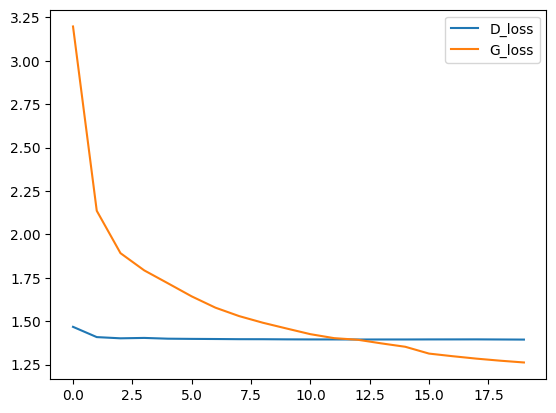

In [22]:

plt.plot(D_loss_list, label='D_loss')
plt.plot(G_loss_list, label='G_loss')
plt.legend()
plt.show()

In [23]:
os.makedirs(save_dir, exist_ok=True)

torch.save(G.state_dict(), os.path.join(save_dir, 'state_dict.pt'))
torch.save(D.state_dict(), os.path.join(save_dir, 'D_state_dict.pt'))
torch.save(G, os.path.join(save_dir, 'G.pt'))
torch.save(D, os.path.join(save_dir, 'D.pt'))

In [24]:
def load_generator_for(dataset_name, device=device):
    model = Generator().to(device)
    ckpt_path = os.path.join('checkpoints', dataset_name, 'state_dict.pt')
    state_dict = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()
    return model


def predict_from_sketch(sketch_path, dataset_name='anime'):
    model = load_generator_for(dataset_name, device=device)
    pil_img = Image.open(sketch_path).convert('RGB')
    x = target_transform(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        y = model(x)

    inp = x[0].detach().cpu().permute(1, 2, 0).numpy()
    out = y[0].detach().cpu().permute(1, 2, 0).numpy()

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.title(f'Input Sketch ({dataset_name})')
    plt.imshow((inp + 1) / 2)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title('Generated Face')
    plt.imshow((out + 1) / 2)
    plt.axis('off')
    plt.show()


## Example usage after training and saving both datasets:
## predict_from_sketch('/path/to/sketch.jpg', dataset_name='anime')
## predict_from_sketch('/path/to/sketch.jpg', dataset_name='cufs')